DataFrame for Number of Hitting Sets by Number of Lines and Alpha (A0&&!A0) is empty. Skipping plot.
Data for Number of Hitting Sets by Number of Lines and Other Alpha Values:
 alpha         (A0&&!A0)  A0||A1
number_lines                   
4                   1.0     0.0
5                  57.0     0.0
6                  34.0     0.0
7                 117.0     0.0
8                 237.0     0.0
9                 555.0     0.0
10               2006.0     0.0
11                824.0     0.0
12               2497.0     0.0
13               4997.0     0.0
14               1059.0   113.0
15               9776.0   738.0
16              19246.0  3589.0
17              10716.0  1393.0
18              10653.0  2127.0
19              10425.0  3084.0
20               6501.0  2463.0
21               1139.0  2617.0
22               3911.0  5751.0
23               1847.0  3667.0
24                  0.0  6525.0
25                  0.0  1012.0


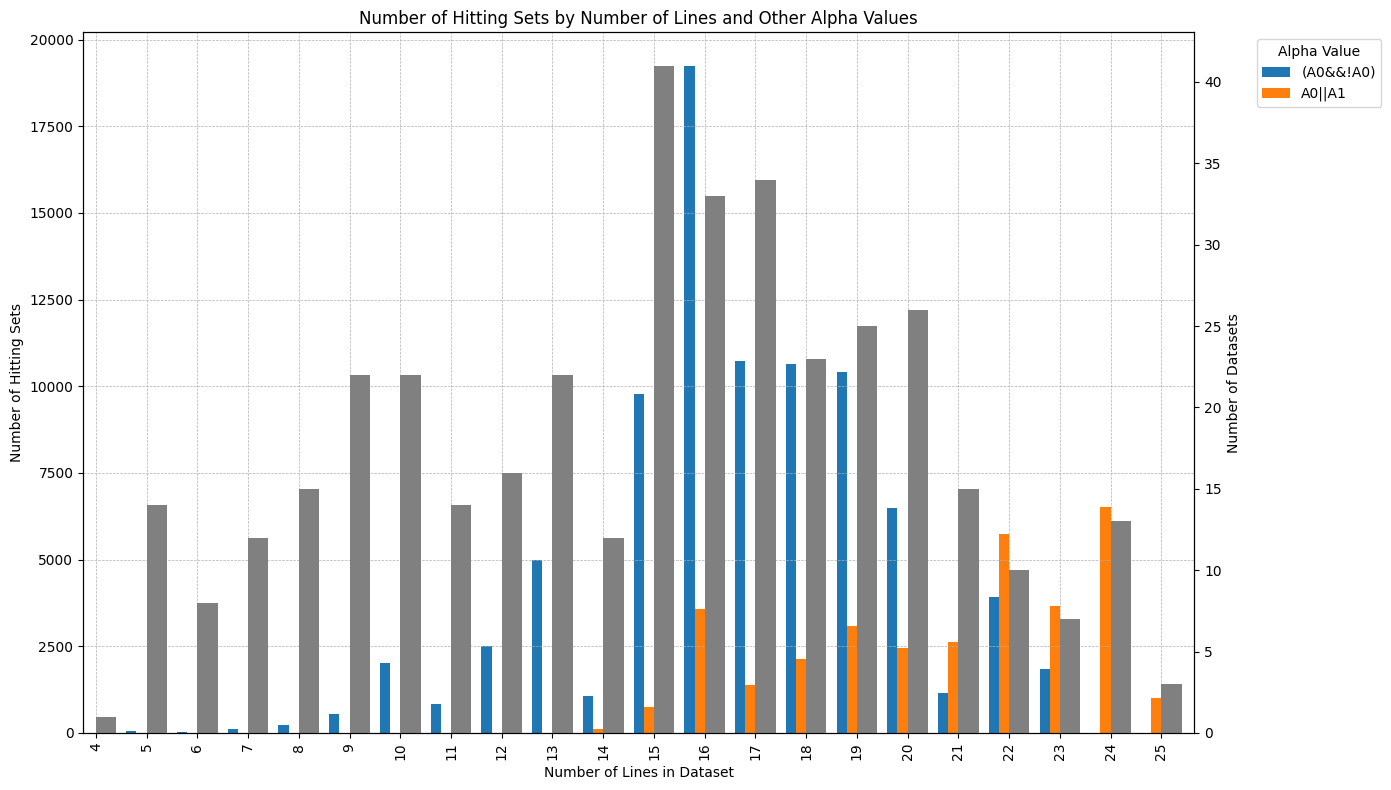

In [1]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV files into Pandas DataFrames
hitting_sets_file = '240730_Hitting_sets.csv'  # Replace with your file path
optimal_file = '240730_OPTIMAL.csv'  # Replace with your file path
data_sets_file = '240730_DATA_SETS.csv'  # Replace with your file path

df_hitting_sets = pd.read_csv(hitting_sets_file, delimiter=';', quotechar='"')
df_optimal = pd.read_csv(optimal_file, delimiter=';', quotechar='"')
df_data_sets = pd.read_csv(data_sets_file, delimiter=';', quotechar='"')

# Count the number of hitting sets for each filename
hitting_set_counts = df_hitting_sets['filename'].value_counts().reset_index()
hitting_set_counts.columns = ['filename', 'hitting_set_count']

# Merge the dataframes on the filename column
df_merged = pd.merge(hitting_set_counts, df_optimal[['filename', 'alpha']], on='filename')
df_merged = pd.merge(df_merged, df_data_sets[['filename', 'number_lines']], on='filename')

# Filter out the ARG datasets
df_merged = df_merged[~df_merged['filename'].str.contains('ARG')]

# Separate datasets with alpha == 'A0&&!A0' and others
df_alpha_A0 = df_merged[df_merged['alpha'] == 'A0&&!A0']
df_other_alpha = df_merged[df_merged['alpha'] != 'A0&&!A0']

# Function to plot data
def plot_data(df, title, filename):
    if df.empty:
        print(f"DataFrame for {title} is empty. Skipping plot.")
        return

    # Group by number of lines and alpha and count the number of hitting sets
    hitting_sets_grouped = df.groupby(['number_lines', 'alpha']).agg({'hitting_set_count': 'sum'}).reset_index()
    
    if hitting_sets_grouped.empty:
        print(f"Grouped data for {title} is empty. Skipping plot.")
        return

    # Pivot the table to have alpha values as columns
    hitting_sets_pivot = hitting_sets_grouped.pivot(index='number_lines', columns='alpha', values='hitting_set_count').fillna(0)

    if hitting_sets_pivot.empty:
        print(f"Pivoted data for {title} is empty. Skipping plot.")
        return

    print(f"Data for {title}:\n", hitting_sets_pivot)

    # Count the number of datasets used per number of lines
    dataset_counts = df[['filename', 'number_lines']].drop_duplicates().groupby('number_lines').size()

    # Plotting
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot the number of hitting sets
    hitting_sets_pivot.plot(kind='bar', stacked=False, ax=ax1, width=0.4, position=1)
    
    # Customize the plot
    ax1.set_title(title)
    ax1.set_xlabel('Number of Lines in Dataset')
    ax1.set_ylabel('Number of Hitting Sets')
    ax1.legend(title='Alpha Value', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Create a secondary y-axis to plot the number of datasets
    ax2 = ax1.twinx()
    dataset_counts.plot(kind='bar', ax=ax2, color='gray', width=0.4, position=0)
    
    # Customize the secondary y-axis
    ax2.set_ylabel('Number of Datasets')
    ax2.grid(False)  # Disable grid on the secondary y-axis
    
    # Save or display the plot
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Plot for datasets with alpha == 'A0&&!A0'
plot_data(df_alpha_A0, 'Number of Hitting Sets by Number of Lines and Alpha (A0&&!A0)', 'hitting_sets_A0.png')

# Plot for datasets with other alpha values
plot_data(df_other_alpha, 'Number of Hitting Sets by Number of Lines and Other Alpha Values', 'hitting_sets_other.png')
